<a href="https://colab.research.google.com/github/AJAXSINGH/DAA-PROJECT/blob/main/DAA4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Text   : AABAACAADAABAABA
Pattern: AABA

Naive Search
Matches     : [0, 9, 12]
Comparisons : 30

KMP Search
Matches     : [0, 9, 12]
Comparisons : 20

Rabin-Karp Search
Matches     : [0, 9, 12]
Comparisons : 12


     Pattern        Naive          KMP           RK
-------------------------------------------------------
          AB       1.9606       2.8857       4.9881
        ABCD       2.1195       1.7900       3.0995
      ABCDAB       1.9760       2.0381       5.3483
    ABCDABCD       5.3996       6.2415      18.4634


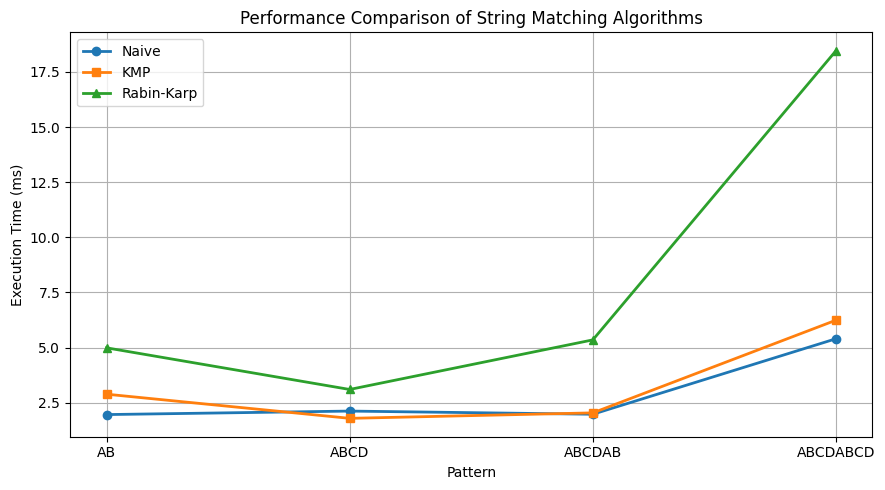

In [1]:
import time
import random
import matplotlib.pyplot as plt


def naive_search(text, pattern):
    """
    Naive String Matching Algorithm
    """
    n = len(text)
    m = len(pattern)

    matches = []
    comparisons = 0

    for i in range(n - m + 1):
        j = 0
        while j < m:
            comparisons += 1
            if text[i + j] != pattern[j]:
                break
            j += 1

        if j == m:
            matches.append(i)

    return matches, comparisons


def compute_lps(pattern):
    """
    Compute Longest Prefix Suffix (LPS) array for KMP.
    """
    m = len(pattern)
    lps = [0] * m

    length = 0
    i = 1

    while i < m:
        if pattern[i] == pattern[length]:
            length += 1
            lps[i] = length
            i += 1
        elif length != 0:
            length = lps[length - 1]
        else:
            lps[i] = 0
            i += 1

    return lps


def kmp_search(text, pattern):
    """
    Knuth-Morris-Pratt (KMP) Algorithm
    """
    n = len(text)
    m = len(pattern)

    lps = compute_lps(pattern)

    matches = []
    comparisons = 0

    i = 0
    j = 0

    while i < n:
        comparisons += 1

        if pattern[j] == text[i]:
            i += 1
            j += 1

            if j == m:
                matches.append(i - j)
                j = lps[j - 1]

        elif i < n:
            if j != 0:
                j = lps[j - 1]
            else:
                i += 1

    return matches, comparisons


def rabin_karp(text, pattern, q=101):
    """
    Rabin-Karp Algorithm
    """
    n = len(text)
    m = len(pattern)

    d = 256
    h = pow(d, m - 1, q)

    p_hash = 0
    t_hash = 0

    matches = []
    comparisons = 0

    for i in range(m):
        p_hash = (d * p_hash + ord(pattern[i])) % q
        t_hash = (d * t_hash + ord(text[i])) % q

    for s in range(n - m + 1):
        if p_hash == t_hash:
            for k in range(m):
                comparisons += 1
                if text[s + k] != pattern[k]:
                    break
            else:
                matches.append(s)

        if s < n - m:
            t_hash = (
                d * (t_hash - ord(text[s]) * h)
                + ord(text[s + m])
            ) % q

            if t_hash < 0:
                t_hash += q

    return matches, comparisons


# ---------------- MAIN PROGRAM ----------------

text = "AABAACAADAABAABA"
pattern = "AABA"

print("Text   :", text)
print("Pattern:", pattern)

m1, c1 = naive_search(text, pattern)
m2, c2 = kmp_search(text, pattern)
m3, c3 = rabin_karp(text, pattern)

print("\nNaive Search")
print("Matches     :", m1)
print("Comparisons :", c1)

print("\nKMP Search")
print("Matches     :", m2)
print("Comparisons :", c2)

print("\nRabin-Karp Search")
print("Matches     :", m3)
print("Comparisons :", c3)

# ---------------- PERFORMANCE ANALYSIS ----------------

text_large = ''.join(random.choices("ABCD", k=10000))
patterns = ["AB", "ABCD", "ABCDAB", "ABCDABCD"]

naive_times = []
kmp_times = []
rk_times = []

print("\n")
print(f"{'Pattern':>12} {'Naive':>12} {'KMP':>12} {'RK':>12}")
print("-" * 55)

for p in patterns:

    start = time.perf_counter()
    for _ in range(100):
        _, comp1 = naive_search(text_large, p)
    naive_time = (time.perf_counter() - start) / 100 * 1000

    start = time.perf_counter()
    for _ in range(100):
        _, comp2 = kmp_search(text_large, p)
    kmp_time = (time.perf_counter() - start) / 100 * 1000

    start = time.perf_counter()
    for _ in range(100):
        _, comp3 = rabin_karp(text_large, p)
    rk_time = (time.perf_counter() - start) / 100 * 1000

    naive_times.append(naive_time)
    kmp_times.append(kmp_time)
    rk_times.append(rk_time)

    print(f"{p:>12} {naive_time:>12.4f} {kmp_time:>12.4f} {rk_time:>12.4f}")

# ---------------- GRAPH ----------------

plt.figure(figsize=(9, 5))

plt.plot(patterns, naive_times,
         marker='o',
         linewidth=2,
         label='Naive')

plt.plot(patterns, kmp_times,
         marker='s',
         linewidth=2,
         label='KMP')

plt.plot(patterns, rk_times,
         marker='^',
         linewidth=2,
         label='Rabin-Karp')

plt.title("Performance Comparison of String Matching Algorithms")
plt.xlabel("Pattern")
plt.ylabel("Execution Time (ms)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()